```shell
unzip /root/autodl-fs/1BAnii.zip -d /root/autodl-fs/nii
unzip /root/autodl-fs/1BBnii.zip -d /root/autodl-fs/nii
unzip /root/autodl-fs/1BCnii.zip -d /root/autodl-fs/nii
```

## 对目录下的ct.nii.gz文件进行处理
### 经过测试,目录和处理都正确, 这套东西的文件目录处理的都很好

In [ ]:
import os
import glob
import SimpleITK as sitk
import numpy as np
import cv2

def apply_window_level(image, window_center, window_width):
    """应用窗宽窗位调整到SimpleITK图像"""
    image = sitk.Cast(image, sitk.sitkFloat32)
    min_val = window_center - window_width/2
    max_val = window_center + window_width/2
    
    window_filter = sitk.IntensityWindowingImageFilter()
    window_filter.SetWindowMinimum(min_val)
    window_filter.SetWindowMaximum(max_val)
    window_filter.SetOutputMinimum(0)
    window_filter.SetOutputMaximum(255)
    
    return window_filter.Execute(image)

def adjust_contrast_volume(np_volume, target_contrast):
    """调整整个volume的对比度"""
    adjusted_volume = cv2.convertScaleAbs(
        np_volume,
        alpha=target_contrast/(np_volume.mean() + 1e-8),
        beta=0
    )
    return adjusted_volume

def resize_volume(np_volume, target_h, target_w):
    """统一调整整个volume的空间尺寸（三维操作）"""
    current_z, current_h, current_w = np_volume.shape
    
    # 高度方向调整
    if current_h > target_h:
        start_h = (current_h - target_h) // 2
        resized = np_volume[:, start_h:start_h+target_h, :]
    else:
        pad_h = target_h - current_h
        resized = np.pad(np_volume, 
                        ((0, 0), (pad_h//2, pad_h - pad_h//2), (0, 0)),
                        mode='constant')
    
    # 宽度方向调整
    current_w_new = resized.shape[2]
    if current_w_new > target_w:
        start_w = (current_w_new - target_w) // 2
        resized = resized[:, :, start_w:start_w+target_w]
    else:
        pad_w = target_w - current_w_new
        resized = np.pad(resized,
                        ((0, 0), (0, 0), (pad_w//2, pad_w - pad_w//2)),
                        mode='constant')
    
    return resized

def process_ct_images(root_dir, output_dir, window_center, window_width, 
                     target_contrast, target_height, target_width):
    """
    处理所有CT图像的主函数
    :param target_height: 目标高度（每个slice的Y轴）
    :param target_width: 目标宽度（每个slice的X轴）
    """
    BENCH_SLICE = 100
    BENCH_D = 213

    os.makedirs(output_dir, exist_ok=True)
    
    file_pattern = os.path.join(root_dir, '**', 'ct.nii.gz')
    for input_path in glob.glob(file_pattern, recursive=True):
        try:
            parent_folder = os.path.basename(os.path.dirname(input_path))
            output_filename = f"{parent_folder}.npy"
            output_path = os.path.join(output_dir, output_filename)

            if os.path.exists(output_path):
                print(f"Skipping existing: {output_path}")
                continue

            # 读取并预处理数据
            img = sitk.ReadImage(input_path)
            
            windowed = apply_window_level(img, window_center, window_width)
            np_volume = sitk.GetArrayFromImage(windowed)  # 维度：(Z,Y,X)
            
            # Z轴切片选择（保持原始depth处理逻辑）
            slice_num = np_volume.shape[0]
            start_slice = BENCH_SLICE + (slice_num - BENCH_D)
            np_volume = np_volume[start_slice:start_slice+TARGET_DEPTH]

            # 调整对比度
            adjusted = adjust_contrast_volume(np_volume, target_contrast)

            # 统一调整空间尺寸（三维操作）
            resized_volume = resize_volume(adjusted, target_height, target_width)
            

            # 保存结果（维度顺序保持Z,Y,X）
            np.save(output_path, resized_volume)
            print(f"Processed: {input_path} -> {output_path}")

        except Exception as e:
            print(f"Error processing {input_path}: {str(e)}")


if __name__ == "__main__":
    input_dir = "/home/featurize/data/Task1_nii/"
    output_dir = "/home/featurize/data/Task1_Liu/CT"
    
    # 目标尺寸参数（根据实际需求修改）
    TARGET_HEIGHT = 256  # 统一调整后的高度（Y轴）
    TARGET_WIDTH = 256   # 统一调整后的宽度（X轴）
    TARGET_DEPTH = 64    # 统一调整后的深度（Z轴）
    WINDOW_CENTER = 32   # CT窗位
    WINDOW_WIDTH = 80    # CT窗宽
    TARGET_CONTRAST = 30 # 对比度调整参数
    
    process_ct_images(
        root_dir=input_dir,
        output_dir=output_dir,
        window_center=WINDOW_CENTER,
        window_width=WINDOW_WIDTH,
        target_contrast=TARGET_CONTRAST,
        target_height=TARGET_HEIGHT,
        target_width=TARGET_WIDTH
    )

Processed: /home/featurize/data/Task1_nii/1BB152/ct.nii.gz -> /home/featurize/data/Task1_Liu/CT/1BB152.npy
Processed: /home/featurize/data/Task1_nii/1BA054/ct.nii.gz -> /home/featurize/data/Task1_Liu/CT/1BA054.npy
Processed: /home/featurize/data/Task1_nii/1BC094/ct.nii.gz -> /home/featurize/data/Task1_Liu/CT/1BC094.npy
Processed: /home/featurize/data/Task1_nii/1BC034/ct.nii.gz -> /home/featurize/data/Task1_Liu/CT/1BC034.npy
Processed: /home/featurize/data/Task1_nii/1BB048/ct.nii.gz -> /home/featurize/data/Task1_Liu/CT/1BB048.npy
Processed: /home/featurize/data/Task1_nii/1BC063/ct.nii.gz -> /home/featurize/data/Task1_Liu/CT/1BC063.npy
Processed: /home/featurize/data/Task1_nii/1BB109/ct.nii.gz -> /home/featurize/data/Task1_Liu/CT/1BB109.npy
Processed: /home/featurize/data/Task1_nii/1BB171/ct.nii.gz -> /home/featurize/data/Task1_Liu/CT/1BB171.npy
Processed: /home/featurize/data/Task1_nii/1BC081/ct.nii.gz -> /home/featurize/data/Task1_Liu/CT/1BC081.npy
Processed: /home/featurize/data/Task1

## 画图查看

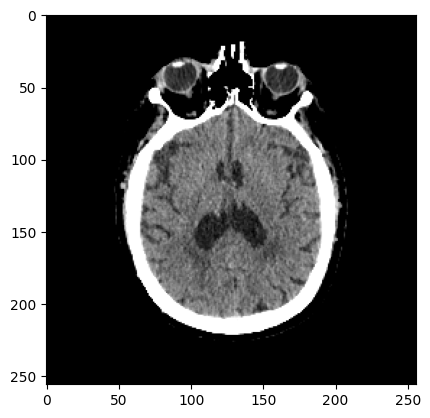

(64, 256, 256)
27.276937246322632
157


In [2]:
import matplotlib.pyplot as plt
process_ct_array = np.load('/home/featurize/data/Task1_Liu/CT/1BA054.npy')
plt.imshow(process_ct_array[30],cmap='gray')
plt.show()
print(process_ct_array.shape)
print(process_ct_array.mean())
print(process_ct_array.max())

## 统计一下训练集的尺寸

In [5]:
import os
import glob
import SimpleITK as sitk
import numpy as np

def get_volume_dims(image_path):
    """获取单个NIfTI文件的维度信息"""
    try:
        img = sitk.ReadImage(image_path)
        size = img.GetSize()  # 返回格式为：(width, height, depth)
        return {
            'W': size[0],  # 宽度
            'H': size[1],  # 高度
            'D': size[2]   # 切片数（深度）
        }
    except Exception as e:
        print(f"Error reading {image_path}: {str(e)}")
        return None

def scan_niigz_dimensions(root_dir):
    """
    扫描目录并统计维度信息
    返回格式：
    {
        "max_dimensions": {"D": max_d, "H": max_h, "W": max_w},
        "all_files": [
            {"path": "file1.nii.gz", "D": d1, "H": h1, "W": w1},
            {"path": "file2.nii.gz", "D": d2, "H": h2, "W": w2},
            ...
        ]
    }
    """
    file_list = []
    min_d, min_h, min_w = 10000, 10000, 10000

    # 递归查找所有.nii.gz文件
    for file_path in glob.glob(os.path.join(root_dir, '**', '*.nii.gz'), recursive=True):
        dims = get_volume_dims(file_path)
        if dims:
            # 更新最大值
            min_d = min(min_d, dims['D'])
            min_h = min(min_h, dims['H'])
            min_w = min(min_w, dims['W'])
            
            # 记录文件信息
            file_list.append({
                "path": os.path.relpath(file_path, root_dir),
                "D": dims['D'],
                "H": dims['H'],
                "W": dims['W']
            })

    return {
        "max_dimensions": {"D": min_d, "H": min_h, "W": min_w},
        "all_files": file_list
    }

def print_statistics(result):
    """格式化打印统计结果"""
    print("维度统计结果：")
    print(f"最大切片数（D）：{result['max_dimensions']['D']}")
    print(f"最大高度（H）：{result['max_dimensions']['H']}")
    print(f"最大宽度（W）：{result['max_dimensions']['W']}")
    
    print("\n详细信息：")
    for file_info in result['all_files']:
        print(f"{file_info['path']}: "
              f"D={file_info['D']}, H={file_info['H']}, W={file_info['W']}")

if __name__ == "__main__":
    # 使用示例
    data_dir = "/root/autodl-tmp/data/nii"
    statistics = scan_niigz_dimensions(data_dir)
    print_statistics(statistics)

    # 可选：保存结果为JSON
    # import json
    # with open("dimension_stats.json", "w") as f:
    #     json.dump(statistics, f, indent=2)

维度统计结果：
最大切片数（D）：10000
最大高度（H）：10000
最大宽度（W）：10000

详细信息：


## 将MR数据进行处理

## 先看一眼胡师兄的数据
### 胡师兄的数据只是把CT调成到对应的窗位窗宽, 然后就没再弄了, 其实CT的还是很亮的
### 然后把MR的对比度调到了50
### 他的数据处理文件位于/home/kccake/Code/Hu_CT2MRI_Project/HX-data/save_AF_01_rename_register_copy.ipynb
#### . 他的CT是先调窗位窗宽,然后直接0-255
#### . 他的MR先缩放的0-255然后,在把对比度调到50, 再把它 (x-127.5)/127.5

In [40]:
# import SimpleITK as sitk
# import numpy as np
# Hu_CT = np.load('/home/kccake/Code/CT2MRI_3DGAN/volume_data_d32/train3D/CT_norm/treated_CAODESHU 0020123088.npy')
# Hu_MR = np.load('/home/kccake/Code/CT2MRI_3DGAN/volume_data_d32/train3D/MRI_norm/treated_CAODESHU 0020123088.npy')
# print(Hu_CT.max())
# print(Hu_MR.max())

1.0
1.0


## 照搬处理CT数据的方式,不过只需要把线性映射做了,对比度调到50,然后Z-normlization

In [5]:
import os
import glob
import SimpleITK as sitk
import numpy as np
import cv2

def adjust_contrast_volume(np_volume, target_contrast):
    """调整整个volume的对比度"""
    adjusted_volume = cv2.convertScaleAbs(
        np_volume,
        alpha=target_contrast/(np_volume.mean() + 1e-8),
        beta=0
    )
    return adjusted_volume

def resize_volume(np_volume, target_h, target_w):
    """统一调整整个volume的空间尺寸（三维操作）"""
    current_z, current_h, current_w = np_volume.shape
    
    # 高度方向调整
    if current_h > target_h:
        start_h = (current_h - target_h) // 2
        resized = np_volume[:, start_h:start_h+target_h, :]
    else:
        pad_h = target_h - current_h
        resized = np.pad(np_volume, 
                        ((0, 0), (pad_h//2, pad_h - pad_h//2), (0, 0)),
                        mode='constant')
    
    # 宽度方向调整
    current_w_new = resized.shape[2]
    if current_w_new > target_w:
        start_w = (current_w_new - target_w) // 2
        resized = resized[:, :, start_w:start_w+target_w]
    else:
        pad_w = target_w - current_w_new
        resized = np.pad(resized,
                        ((0, 0), (0, 0), (pad_w//2, pad_w - pad_w//2)),
                        mode='constant')
    
    return resized

def process_mr_images(root_dir, output_dir, target_contrast, target_height, target_width):
    """
    处理所有MR图像的主函数
    :param root_dir: 包含MR图像的根目录
    :param output_dir: 处理后的输出目录
    :param target_contrast: 目标对比度
    :param target_height: 目标高度
    :param target_width: 目标宽度
    """
    BENCH_SLICE = 100
    BENCH_D = 213

    os.makedirs(output_dir, exist_ok=True)
    
    file_pattern = os.path.join(root_dir, '**', 'mr.nii.gz')
    for input_path in glob.glob(file_pattern, recursive=True):
        try:
            parent_folder = os.path.basename(os.path.dirname(input_path))
            output_filename = f"{parent_folder}.npy"
            output_path = os.path.join(output_dir, output_filename)

            if os.path.exists(output_path):
                print(f"Skipping existing: {output_path}")
                continue

            # 处理流程
            img = sitk.ReadImage(input_path)
            np_volume = sitk.GetArrayFromImage(img)  # (Z,Y,X)

            # Z轴切片选择
            slice_num = np_volume.shape[0]
            start_slice = BENCH_SLICE + (slice_num - BENCH_D)
            np_volume = np_volume[start_slice:start_slice+TARGET_DEPTH]

            # 线性归一化到0-255
            np_volume = (np_volume - np_volume.min()) / (np_volume.max() - np_volume.min()) * 255

            # 调整对比度
            adjusted = adjust_contrast_volume(np_volume, target_contrast)

            # 调整空间尺寸
            resized_volume = resize_volume(adjusted, target_height, target_width)

            # 归一化到(-1,1)范围
            final_volume = (resized_volume - 127.5) / 127.5

            # 保存结果
            np.save(output_path, final_volume)
            print(f"Processed: {input_path} -> {output_path}")

        except Exception as e:
            print(f"Error processing {input_path}: {str(e)}")

if __name__ == "__main__":
    input_dir = "/home/featurize/data/Task1_nii/"
    output_dir = "/home/featurize/data/Task1_Liu/MR"
    
    # 新增尺寸参数（保持与CT处理一致）
    TARGET_HEIGHT = 256
    TARGET_WIDTH = 256
    TARGET_DEPTH = 64
    TARGET_CONTRAST = 30
    
    process_mr_images(
        root_dir=input_dir,
        output_dir=output_dir,
        target_contrast=TARGET_CONTRAST,
        target_height=TARGET_HEIGHT,
        target_width=TARGET_WIDTH
    )

Skipping existing: /home/featurize/data/Task1_Liu/MR/1BB152.npy
Skipping existing: /home/featurize/data/Task1_Liu/MR/1BA054.npy
Skipping existing: /home/featurize/data/Task1_Liu/MR/1BC094.npy
Skipping existing: /home/featurize/data/Task1_Liu/MR/1BC034.npy
Skipping existing: /home/featurize/data/Task1_Liu/MR/1BB048.npy
Skipping existing: /home/featurize/data/Task1_Liu/MR/1BC063.npy
Skipping existing: /home/featurize/data/Task1_Liu/MR/1BB109.npy
Skipping existing: /home/featurize/data/Task1_Liu/MR/1BB171.npy
Skipping existing: /home/featurize/data/Task1_Liu/MR/1BC081.npy
Skipping existing: /home/featurize/data/Task1_Liu/MR/1BA116.npy
Skipping existing: /home/featurize/data/Task1_Liu/MR/1BA085.npy
Skipping existing: /home/featurize/data/Task1_Liu/MR/1BC058.npy
Skipping existing: /home/featurize/data/Task1_Liu/MR/1BC067.npy
Skipping existing: /home/featurize/data/Task1_Liu/MR/1BA014.npy
Skipping existing: /home/featurize/data/Task1_Liu/MR/1BC010.npy
Skipping existing: /home/featurize/data/

## 查看MR的效果

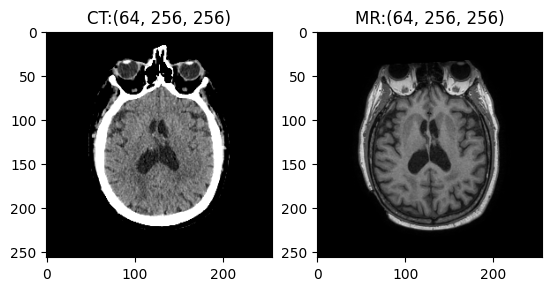

In [4]:
mr_array = np.load('/home/featurize/data/Task1_Liu/MR/1BA054.npy')
ct_array = np.load('/home/featurize/data/Task1_Liu/CT/1BA054.npy')

plt.subplot(1,2,1)
plt.imshow(ct_array[32],cmap='gray')
plt.title(f'CT:{mr_array.shape}')

plt.subplot(1,2,2)
plt.imshow(mr_array[32],cmap='gray')
plt.title(f'MR:{ct_array.shape}')

plt.show()

## 将数据集划分为训练集和测试集

In [4]:
import os
import glob
import shutil
import numpy as np
from sklearn.model_selection import train_test_split

def organize_dataset(root_dir):
    """组织数据集结构，返回病例列表"""
    # 假设数据结构：
    # root_dir/
    # ├── CT/
    # │   ├── case_001.nii.gz
    # │   └── case_002.nii.gz
    # └── MR/
    #     ├── case_001.nii.gz
    #     └── case_002.nii.gz
    
    ct_files = glob.glob(os.path.join(root_dir, 'CT', '*.npy'))
    mr_files = glob.glob(os.path.join(root_dir, 'MR', '*.npy'))
    
    # 提取唯一病例ID（假设文件名格式为case_id.nii.gz）
    ct_case_ids = [os.path.basename(f).split('.')[0] for f in ct_files]
    mr_case_ids = [os.path.basename(f).split('.')[0] for f in mr_files]

    # 验证病例匹配性
    common_cases = set(ct_case_ids) & set(mr_case_ids)
    if len(common_cases) != len(ct_case_ids) or len(common_cases) != len(mr_case_ids):
        print("警告：存在不匹配的CT/MR病例")
    
    return sorted(list(common_cases))

def split_dataset(case_ids, test_size=0.2, random_state=42):
    """划分训练集和测试集"""
    train_ids, test_ids = train_test_split(
        case_ids,
        test_size=test_size,
        random_state=random_state,
        shuffle=True
    )
    return train_ids, test_ids

def create_dataset_structure(output_dir):
    """创建标准目录结构"""
    os.makedirs(os.path.join(output_dir, 'train', 'CT'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'train', 'MR'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'val', 'CT'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'val', 'MR'), exist_ok=True)

def copy_files(src_root, dst_root, case_ids, modality):
    """复制指定病例的.npy文件"""
    for case_id in case_ids:
        # 源路径和目标路径使用.npy后缀
        src_path = os.path.join(src_root, modality, f"{case_id}.npy")
        dst_dir = os.path.join(dst_root, modality)
        dst_path = os.path.join(dst_dir, f"{case_id}.npy")
        
        # 确保目标目录存在
        os.makedirs(dst_dir, exist_ok=True)
        
        if os.path.exists(src_path):
            try:
                shutil.copy(src_path, dst_path)
                print(f"成功复制 {modality}/{case_id}.npy 到 {dst_path}")
            except Exception as e:
                print(f"复制失败 {src_path}: {str(e)}")
        else:
            print(f"警告：找不到 {modality} 文件 {case_id}.npy")

def main():
    # 参数配置
    # input_dir = "/path/to/raw_dataset"  # 原始数据目录
    # output_dir = "/path/to/split_dataset"  # 划分后输出目录
    input_dir = '/home/featurize/data/Task1_Liu'
    output_dir = '/home/featurize/data/Task1_Liu_split'
    test_ratio = 0.2  # 测试集比例
    random_seed = 42  # 随机种子
    
    # 步骤1：整理数据集
    case_ids = organize_dataset(input_dir)
    print(f"找到 {len(case_ids)} 个完整病例")
    
    # 步骤2：划分数据集
    train_ids, test_ids = split_dataset(case_ids, test_ratio, random_seed)
    print(f"训练集：{len(train_ids)} 病例")
    print(f"测试集：{len(test_ids)} 病例")
    
    # 步骤3：创建目录结构
    create_dataset_structure(output_dir)
    
    # 步骤4：复制文件
    # 复制训练集
    copy_files(input_dir, os.path.join(output_dir, 'train'), train_ids, 'CT')
    copy_files(input_dir, os.path.join(output_dir, 'train'), train_ids, 'MR')
    
    # 复制测试集
    copy_files(input_dir, os.path.join(output_dir, 'val'), test_ids, 'CT')
    copy_files(input_dir, os.path.join(output_dir, 'val'), test_ids, 'MR')

if __name__ == "__main__":
    main()

找到 180 个完整病例
训练集：144 病例
测试集：36 病例
成功复制 CT/1BB198.npy 到 /home/featurize/data/Task1_Liu_split/train/CT/1BB198.npy
成功复制 CT/1BB008.npy 到 /home/featurize/data/Task1_Liu_split/train/CT/1BB008.npy
成功复制 CT/1BB016.npy 到 /home/featurize/data/Task1_Liu_split/train/CT/1BB016.npy
成功复制 CT/1BA185.npy 到 /home/featurize/data/Task1_Liu_split/train/CT/1BA185.npy
成功复制 CT/1BA085.npy 到 /home/featurize/data/Task1_Liu_split/train/CT/1BA085.npy
成功复制 CT/1BA253.npy 到 /home/featurize/data/Task1_Liu_split/train/CT/1BA253.npy
成功复制 CT/1BC008.npy 到 /home/featurize/data/Task1_Liu_split/train/CT/1BC008.npy
成功复制 CT/1BB098.npy 到 /home/featurize/data/Task1_Liu_split/train/CT/1BB098.npy
成功复制 CT/1BC067.npy 到 /home/featurize/data/Task1_Liu_split/train/CT/1BC067.npy
成功复制 CT/1BC022.npy 到 /home/featurize/data/Task1_Liu_split/train/CT/1BC022.npy
成功复制 CT/1BB075.npy 到 /home/featurize/data/Task1_Liu_split/train/CT/1BB075.npy
成功复制 CT/1BA234.npy 到 /home/featurize/data/Task1_Liu_split/train/CT/1BA234.npy
成功复制 CT/1BC080.npy 到 /home/fea

## 检查一下,是否执行正确
### 执行正确

In [ ]:
array_ori = np.load('/root/autodl-tmp/data/nii/MR/1BA005.npy')
array_split = np.load('/root/autodl-tmp/data/synth2023/train/MR/1BA005.npy')
print((array_ori==array_split).all())

True
